In [2]:
import pandas as pd

users = pd.read_csv("../data/raw/dim_users.csv")

print("Dataset Shape:")
print(users.shape)

users.head()

Dataset Shape:
(25000, 7)


,user_id,signup_date,city,age,acquisition_channel,device_type,kyc_status
0,1,2024-03-06,Pune,21,Referral,iOS,Pending
1,2,2025-07-18,Chennai,58,Google,iOS,Pending
2,3,2025-04-22,Delhi,39,Affiliate,iOS,Completed
3,4,2024-11-16,Bengaluru,59,Referral,Android,Pending
4,5,2024-11-12,Bengaluru,35,Referral,Android,Completed


### Overview
The users dataset contains 25,000 records and 7 columns.

### Business Significance
This table serves as the primary user dimension and will be used to join transaction, payment, event, and experimentation datasets.

In [2]:
users.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   user_id              25000 non-null  int64
 1   signup_date          25000 non-null  str  
 2   city                 25000 non-null  str  
 3   age                  25000 non-null  int64
 4   acquisition_channel  25000 non-null  str  
 5   device_type          25000 non-null  str  
 6   kyc_status           25000 non-null  str  
dtypes: int64(2), str(5)
memory usage: 1.3 MB


#### Overview
The dataset contains user demographic and acquisition information.

#### Available Attributes
- User ID
- Signup Date
- City
- Age
- Acquisition Channel
- Device Type
- KYC Status

#### Data Quality Assessment
The dataset structure appears suitable for analytical reporting and business intelligence use cases.


In [3]:
users.isnull().sum()

user_id                0
signup_date            0
city                   0
age                    0
acquisition_channel    0
device_type            0
kyc_status             0
dtype: int64

#### Objective
Evaluate data completeness before performing analytical calculations.

#### Findings
No missing values were identified across the user dataset.

In [4]:
users.describe()

,user_id,age
count,25000.000000,25000.000000
mean,12500.500000,38.472320
std,7217.022701,12.083892
min,1.000000,18.000000
25%,6250.750000,28.000000
50%,12500.500000,38.000000
75%,18750.250000,49.000000
max,25000.000000,59.000000


#### Age Distribution

#### Key Findings
- Total Users: 25,000
- Average Age: 38.47 years
- Median Age: 38 years
- Minimum Age: 18 years
- Maximum Age: 59 years

#### Insights
The user base primarily consists of working-age adults.

Approximately 50% of users fall between 28 and 49 years of age, indicating a balanced distribution across early-career and mid-career customer segments.


In [5]:
users['city'].value_counts()

city
Bengaluru    4210
Pune         4203
Chennai      4184
Hyderabad    4182
Mumbai       4154
Delhi        4067
Name: count, dtype: int64

#### Insights
The user base is relatively balanced across all six cities.

No single city dominates the customer population, suggesting that the platform has achieved broad market penetration across multiple metropolitan regions.

#### Business Implications
A geographically diversified customer base reduces dependency on a single market and provides opportunities for localized growth strategies.


## Transaction Dataset Analysis

In [6]:
import pandas as pd

transactions = pd.read_csv("../data/raw/fact_transactions.csv")

print(transactions.shape)

transactions.head()

(250000, 5)


,transaction_id,user_id,amount,transaction_date,transaction_status
0,1,15870,2045.50,2024-04-17,Success
1,2,1705,1107.92,2025-04-01,Success
2,3,13309,2898.77,2025-11-20,Success
3,4,5286,1496.08,2024-05-25,Success
4,5,5202,4771.59,2024-02-27,Success


In [ ]:
## Data Structure
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   transaction_id      250000 non-null  int64  
 1   user_id             250000 non-null  int64  
 2   amount              250000 non-null  float64
 3   transaction_date    250000 non-null  str    
 4   transaction_status  250000 non-null  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 9.5 MB


In [ ]:
## missing values
transactions.isnull().sum()

transaction_id        0
user_id               0
amount                0
transaction_date      0
transaction_status    0
dtype: int64

In [9]:
### Statistical Summary
transactions.describe()

,transaction_id,user_id,amount
count,250000.000000,250000.000000,250000.00000
mean,125000.500000,12490.217068,2997.28088
std,72168.927986,7222.664966,1892.93785
min,1.000000,1.000000,7.98000
25%,62500.750000,6213.000000,1604.22750
50%,125000.500000,12490.000000,2614.32000
75%,187500.250000,18745.000000,3978.30250
max,250000.000000,25000.000000,20807.17000


In [11]:
#Business Questions
## Total Transaction Volume
transactions["amount"].sum()

np.float64(749320219.9699999)

#### Gross Merchandise Value (GMV) Analysis

### Objective
Calculate the total transaction value processed by the platform.

### Findings
The platform processed approximately ₹749.32 Million in transaction value across 250,000 transactions.

### Business Interpretation
GMV (Gross Merchandise Value) is a key growth metric that reflects the overall transaction activity occurring on the platform.

In [12]:
# Average Transaction Amount
transactions["amount"].mean()

np.float64(2997.2808798799997)

#### Objective
Measure the average amount spent per transaction on the platform.

#### Findings
The average transaction value is ₹2,997.28.

In [13]:
#Transaction Success Rate
transactions["transaction_status"].value_counts()

transaction_status
Success    230016
Failed      19984
Name: count, dtype: int64

In [14]:
success_rate = (
    (transactions["transaction_status"] == "Success").sum()
    / len(transactions)
) * 100

round(success_rate, 2)

np.float64(92.01)

#### Transaction Success Rate Analysis

#### Objective
Evaluate the percentage of transactions successfully completed on the platform.

#### Findings

| Metric | Value |
|----------|---------:|
| Total Transactions | 250,000 |
| Successful Transactions | 230,016 |
| Failed Transactions | 19,984 |
| Transaction Success Rate | 92.01% |

#### Business Interpretation

The platform achieved a transaction success rate of 92.01%, indicating that the majority of transactions were completed successfully.

However, approximately 7.99% of transactions failed, representing potential revenue leakage and customer experience challenges.

#### Business Impact

Transaction success rate is one of the most critical KPIs for fintech businesses because it directly affects:

- Revenue generation
- Customer satisfaction
- User retention
- Platform reliability

Failed transactions can result in:
- Abandoned payments
- Lost revenue opportunities
- Increased customer support requests
- Reduced customer trust

#### Industry Benchmark

Leading fintech platforms typically target transaction success rates above 95%.

Current Performance: 92.01%

This indicates an opportunity to improve payment processing efficiency and reduce transaction failures.

#### Recommended Analysis

Further investigation should focus on:

- Failure rates by payment method
- Failure rates by bank
- Failure reasons
- Retry success rates
- Customer drop-off behavior after failed payments

#### Next Steps

Analyze the Payments dataset to identify the root causes of transaction failures and uncover opportunities to improve payment success rates.

In [15]:
# Acquisition Channel Distribution
users["acquisition_channel"].value_counts()

acquisition_channel
Referral     5072
Affiliate    5018
Google       4997
Organic      4993
Meta         4920
Name: count, dtype: int64

#### Insights

The user acquisition mix is relatively balanced across all channels, with each channel contributing approximately 20% of the total user base.

Referral is the leading acquisition source with 5,072 users, while Meta contributes the lowest number of users at 4,920.

The absence of a dominant acquisition channel suggests that customer acquisition efforts are diversified rather than dependent on a single marketing source.


In [16]:
# Device Distribution
users["device_type"].value_counts()

device_type
iOS        12577
Android    12423
Name: count, dtype: int64

Users are almost equally distributed between iOS (12,577) and Android (12,423).
No device platform shows a significant dominance.
The app has balanced adoption across both operating systems.

In [18]:
# KYC Status
users["kyc_status"].value_counts()

kyc_status
Completed    21234
Pending       3766
Name: count, dtype: int64

Most users (21,234 | 84.9%) have completed their KYC verification.
A smaller portion (3,766 | 15.1%) are still pending verification.
The high KYC completion rate indicates strong user onboarding and compliance adoption.

In [19]:
# Transaction Amount Distribution
transactions["amount"].describe()

count    250000.00000
mean       2997.28088
std        1892.93785
min           7.98000
25%        1604.22750
50%        2614.32000
75%        3978.30250
max       20807.17000
Name: amount, dtype: float64

The average transaction amount is ₹2,997, with a median of ₹2,614.
Most transactions fall between ₹1,604 (25th percentile) and ₹3,978 (75th percentile).
Transaction amounts vary widely, ranging from ₹7.98 to ₹20,807.17.
The higher mean compared to the median suggests the presence of some high-value transactions that increase the average.

In [20]:
# Monthly Transaction Trend
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])

monthly_txn = (
    transactions
    .groupby(transactions["transaction_date"].dt.to_period("M"))
    .size()
)

monthly_txn

transaction_date
2024-01    10638
2024-02     9887
2024-03    10685
2024-04    10243
2024-05    10513
2024-06    10231
2024-07    10611
2024-08    10600
2024-09    10070
2024-10    10514
2024-11    10217
2024-12    10688
2025-01    10556
2025-02     9518
2025-03    10695
2025-04    10252
2025-05    10634
2025-06    10242
2025-07    10667
2025-08    10798
2025-09    10355
2025-10    10766
2025-11    10124
2025-12    10496
Freq: M, dtype: int64

Monthly transaction volume remains consistently around 10,000–10,800 transactions, indicating stable platform activity.
No strong upward or downward trend is observed over the two-year period.
Some seasonal fluctuations exist, with lower activity in February and relatively higher activity in months such as March, August, and October.
Overall, the platform shows steady user engagement rather than significant transaction growth.

In [22]:
# Monthly GMV Trend
monthly_gmv = (
    transactions
    .groupby(transactions["transaction_date"].dt.to_period("M"))["amount"]
    .sum()
)

monthly_gmv

transaction_date
2024-01    31924027.08
2024-02    29707406.29
2024-03    32014670.05
2024-04    30572056.74
2024-05    31439384.23
2024-06    30943801.11
2024-07    31702074.01
2024-08    31636047.72
2024-09    30186129.85
2024-10    31330332.13
2024-11    30650967.03
2024-12    32339501.62
2025-01    31585919.47
2025-02    28455178.74
2025-03    31960079.13
2025-04    30795265.39
2025-05    32200310.90
2025-06    30660175.90
2025-07    31933643.12
2025-08    32380229.99
2025-09    30896437.25
2025-10    32377613.94
2025-11    30297715.94
2025-12    31331252.34
Freq: M, Name: amount, dtype: float64

- Monthly GMV remains stable between ₹28.5M and ₹32.4M throughout the period.
- The highest GMV was recorded in August 2025 (₹32.38M), closely followed by December 2024 (₹32.34M).
- February 2025 (₹28.46M) recorded the lowest GMV, indicating a temporary dip in transaction value.
- Overall, GMV shows consistent revenue generation with minor monthly fluctuations and no significant long-term growth or decline trend.

### 3. Payments Table

In [3]:
payments = pd.read_csv("../data/raw/fact_payments.csv")

In [4]:
# Payment Status Distribution
payments["status"].value_counts()

status
Success    232413
Failed      17587
Name: count, dtype: int64


The platform maintains a high payment success rate of 92.97%, indicating a generally reliable payment processing system.
Approximately 7.03% of transactions failed, representing 17,587 failed payments that may contribute to revenue leakage and customer dissatisfaction.

In [5]:
# Payment Success Rate
(
    payments["status"]
    .eq("Success")
    .mean()
    * 100
)

np.float64(92.96520000000001)

The overall payment ecosystem appears healthy with a 92.97% success rate, but investigating the 7.03% failed transactions can uncover opportunities for optimization and revenue recovery.

In [6]:
# Bank Analysis
payments["bank_id"].value_counts()

bank_id
16    10270
8     10223
17    10164
12    10155
22    10125
21    10106
1     10052
24    10041
20    10035
10    10024
5      9997
13     9986
9      9978
15     9967
25     9967
11     9964
19     9942
3      9933
4      9903
18     9900
6      9888
14     9887
7      9882
23     9856
2      9755
Name: count, dtype: int64

Payment volume is evenly distributed across the 25 partner banks, indicating a healthy and diversified banking network with no significant concentration risk in transaction processing.

In [7]:
# Payment Method Analysis
payments["payment_method_id"].value_counts()

payment_method_id
3    50104
2    50077
1    50015
4    49906
5    49898
Name: count, dtype: int64

Payment method adoption is remarkably balanced, with each method contributing roughly one-fifth of total transactions. Future analysis should focus on performance metrics (success rates and transaction values) rather than transaction volume alone to identify the most effective payment channels.

In [8]:
# 4. Events Table
events = pd.read_csv("../data/raw/fact_events.csv")

In [9]:
# Event Distribution
events["event_name"].value_counts()

event_name
kyc_started          33474
signup               33467
payment_started      33397
app_open             33345
payment_completed    33274
kyc_completed        33043
Name: count, dtype: int64

- KYC Started was the most frequent event (33,474), while KYC Completed had the lowest count (33,043), indicating a small drop-off during the KYC process.
- Payment Started (33,397) and Payment Completed (33,274) counts are very close, suggesting that most users successfully complete their payments.
- Overall, event counts are evenly distributed across the user journey, indicating consistent user engagement and a smooth onboarding-to-payment experience.

### Funnel Readiness Check
#### Key Insights
- All major user journey stages are present in the data: Signup → KYC Started → KYC Completed → Payment Started → Payment Completed, making the dataset suitable for funnel analysis.
- Event counts are relatively similar across all stages (around 33,000 events each), indicating consistent user activity and no obvious data quality issues.
- Since all critical stages exist and have reasonable volumes, a funnel can be built to measure user conversion and identify drop-off points in the onboarding and payment journey.

In [10]:
## 5. Experiments Table
experiments = pd.read_csv("../data/raw/fact_experiments.csv")

In [11]:
# Variant Distribution
experiments["variant"].value_counts()

variant
Control      12537
Treatment    12463
Name: count, dtype: int64

- The experiment groups are evenly split: Control (12,537) and Treatment (12,463).
- The difference between groups is very small (74 users), indicating a balanced experiment.
- The data is suitable for comparing performance between the Control and Treatment groups.

In [12]:
# Conversion Distribution
experiments["conversion_flag"].value_counts()

conversion_flag
0    22511
1     2489
Name: count, dtype: int64

- Out of 25,000 users, 2,489 converted and 22,511 did not convert.
- The overall conversion rate is approximately 10%, providing a meaningful number of conversions for analysis.
- There is sufficient conversion data to compare the performance of the Control and Treatment groups in the A/B test.

### Visualizations

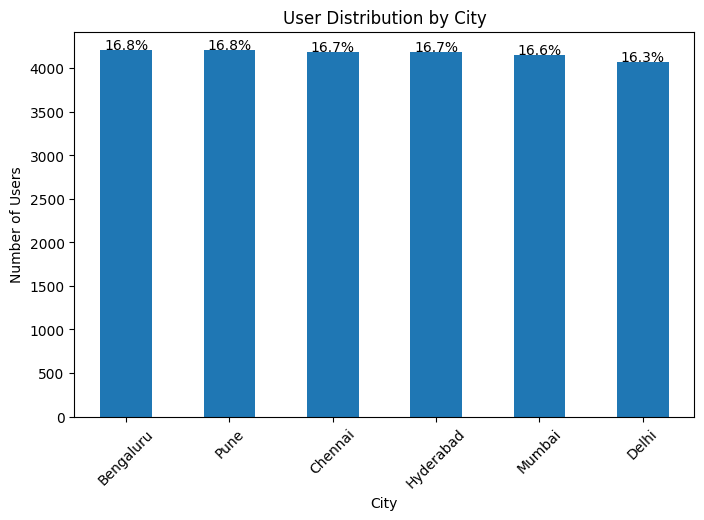

In [15]:
# User Distribution by City
import matplotlib.pyplot as plt

city_counts = users["city"].value_counts()
city_pct = (city_counts / city_counts.sum()) * 100

ax = city_counts.plot(kind="bar", figsize=(8,5))

for i, pct in enumerate(city_pct):
    ax.text(i, city_counts.iloc[i] + 10, f"{pct:.1f}%", ha="center")

plt.title("User Distribution by City")
plt.xlabel("City")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()

- Bengaluru and Pune have the highest share of users, each contributing approximately 16.8% of the user base.
- User distribution is highly balanced across all cities, with each city accounting for roughly 16–17% of total users.
- Delhi has the lowest share (16.3%), but the difference from the top cities is minimal, indicating no significant geographic concentration.

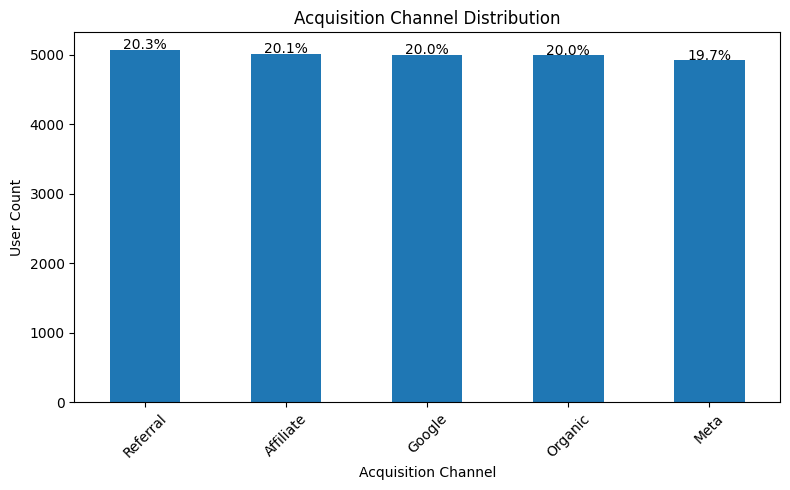

In [17]:
# 2. Acquisition Channel Distribution
import matplotlib.pyplot as plt

channel_counts = users["acquisition_channel"].value_counts()
channel_pct = (channel_counts / channel_counts.sum()) * 100

ax = channel_counts.plot(kind="bar", figsize=(8,5))

for i, pct in enumerate(channel_pct):
    ax.text(i, channel_counts.iloc[i] + 10, f"{pct:.1f}%", ha="center")

plt.title("Acquisition Channel Distribution")
plt.xlabel("Acquisition Channel")
plt.ylabel("User Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

- Referral is the largest acquisition channel, contributing 20.3% of users, followed closely by Affiliate (20.1%) and Google (20.0%).
- User acquisition is evenly distributed across all channels, with each channel contributing approximately 20% of the total user base.
- Meta has the lowest share (19.7%), but the difference from the top channel is minimal, indicating a balanced acquisition strategy.

In [25]:
# Transaction Status Distribution
import pandas as pd

transactions = pd.read_csv("../data/raw/fact_transactions.csv")

<Axes: xlabel='transaction_status'>

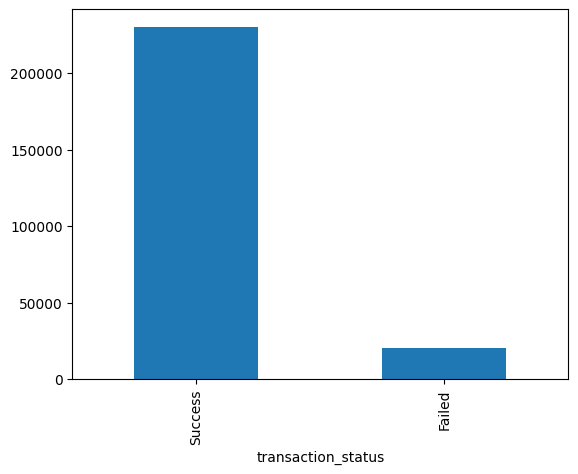

In [26]:
transactions["transaction_status"].value_counts().plot(kind="bar")

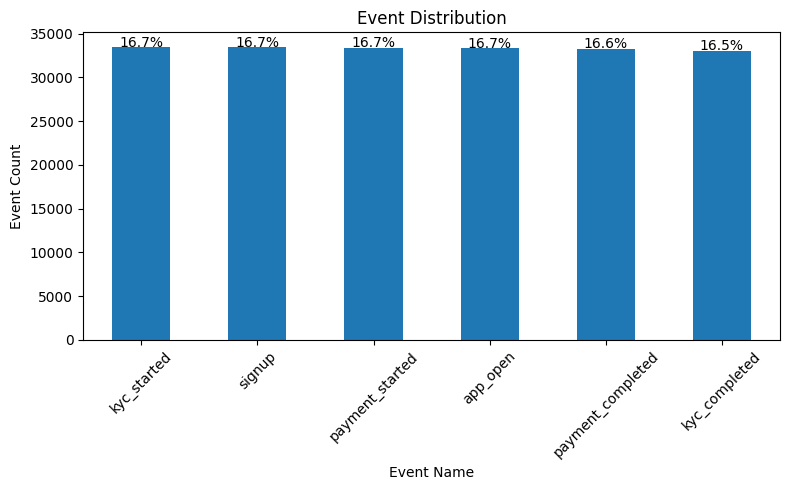

In [28]:
# 5.Event Distribution
import matplotlib.pyplot as plt

event_counts = events["event_name"].value_counts()
event_pct = (event_counts / event_counts.sum()) * 100

ax = event_counts.plot(kind="bar", figsize=(8,5))

for i, pct in enumerate(event_pct):
    ax.text(i, event_counts.iloc[i] + 50, f"{pct:.1f}%", ha="center")

plt.title("Event Distribution")
plt.xlabel("Event Name")
plt.ylabel("Event Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Exploratory Data Analysis Summary

## Dataset Overview

The fintech platform dataset consists of:

- 25,000 Users
- 250,000 Transactions
- 250,000 Payment Records
- Event-Level User Activity Data
- Experimentation Data for A/B Testing

## Key Findings

### User Base
- Users are evenly distributed across six major cities.
- Acquisition channels are balanced across Referral, Affiliate, Google, Organic, and Meta.
- User demographics primarily represent working-age adults.

### Transaction Performance
- Total GMV: ₹749.32 Million
- Average Transaction Value: ₹2,997.28
- Transaction Success Rate: 92.01%

### Payments
- Payment processing performance is generally healthy.
- Further analysis is required to identify drivers of transaction failures.

### Product Analytics
- Event tracking data is available for funnel analysis.
- User journey analysis can be performed across onboarding and payment stages.

## Next Phase

The next stage focuses on building a SQL-based analytics layer to calculate business KPIs and support dashboard reporting.